In [2]:
import dlib
print("All imports successful!")
!pip install scikit-learn
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All imports successful!
All libraries imported successfully!
TensorFlow version: 2.13.0


In [4]:
import os
import cv2

# Define the base dataset directory
base_dir = r'C:\Users\Admin\Downloads\Compressed\FaceForensics++'

# Define video directories
real_video_dir = os.path.join(base_dir, 'real')
fake_video_dir = os.path.join(base_dir, 'fake')

# Define output directories for extracted frames (to be saved in the same main directory)
extracted_real_dir = os.path.join(base_dir, 'extracted_real')
extracted_fake_dir = os.path.join(base_dir, 'extracted_fake')

# Create output directories if they don't exist
os.makedirs(extracted_real_dir, exist_ok=True)
os.makedirs(extracted_fake_dir, exist_ok=True)


In [ ]:


# Function to extract frames from a video file
def extract_frames(video_path, output_dir, frame_interval=30):
    cap = cv2.VideoCapture(video_path)
    count = 0
    saved_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            filename = os.path.join(output_dir, f'{os.path.basename(video_path).split(".")[0]}_frame_{saved_count:05d}.jpg')
            cv2.imwrite(filename, frame)
            saved_count += 1
        count += 1
    cap.release()
    print(f"Extracted {saved_count} frames from {os.path.basename(video_path)}")

# Process videos in the "real" folder
for file in os.listdir(real_video_dir):
    if file.lower().endswith('.mp4'):
        video_file = os.path.join(real_video_dir, file)
        extract_frames(video_file, extracted_real_dir)

# Process videos in the "fake" folder
for file in os.listdir(fake_video_dir):
    if file.lower().endswith('.mp4'):
        video_file = os.path.join(fake_video_dir, file)
        extract_frames(video_file, extracted_fake_dir)


In [8]:
import os
import shutil

# Define the source directories (where the extracted frames are currently stored)
source_real_dir = os.path.join(base_dir, 'extracted_real')
source_fake_dir = os.path.join(base_dir, 'extracted_fake')

# Define the destination directories (flat structure)
flat_data_dir = os.path.join(base_dir, 'data_flat')
flat_real_dir = os.path.join(flat_data_dir, 'real')
flat_fake_dir = os.path.join(flat_data_dir, 'fake')

# Create the flat directories if they don't exist
os.makedirs(flat_real_dir, exist_ok=True)
os.makedirs(flat_fake_dir, exist_ok=True)



# Function to copy images from nested folders to a flat folder
def flatten_folder(source_dir, dest_dir):
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png')):
                src_file = os.path.join(root, file)
                dest_file = os.path.join(dest_dir, file)
                # In case of duplicate file names, you can add a unique prefix or suffix
                if os.path.exists(dest_file):
                    dest_file = os.path.join(dest_dir, f"{os.path.basename(root)}_{file}")
                shutil.copy(src_file, dest_file)


# Flatten the "real" images
flatten_folder(source_real_dir, flat_real_dir)
# Flatten the "fake" images
flatten_folder(source_fake_dir, flat_fake_dir)

print("Flattening complete. Check the 'data_flat' folder in your FaceForensics++ directory.")



In [10]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load VGG19 pre-trained model (exclude top layers)
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Build complete model
model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_flat_dir = os.path.join(base_dir, 'data_flat')

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    data_flat_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    data_flat_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 8453 images belonging to 2 classes.
Found 2112 images belonging to 2 classes.


In [11]:
epochs = 10

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)


Epoch 1/10
265/265 [==============================] - 645s 2s/step - loss: 0.7220 - accuracy: 0.5279 - val_loss: 0.6965 - val_accuracy: 0.5152
Epoch 2/10
265/265 [==============================] - 636s 2s/step - loss: 0.6734 - accuracy: 0.5837 - val_loss: 0.7035 - val_accuracy: 0.5104
Epoch 3/10
265/265 [==============================] - 635s 2s/step - loss: 0.6519 - accuracy: 0.6274 - val_loss: 0.7104 - val_accuracy: 0.5194
Epoch 4/10
265/265 [==============================] - 635s 2s/step - loss: 0.6368 - accuracy: 0.6490 - val_loss: 0.7163 - val_accuracy: 0.5156
Epoch 5/10
265/265 [==============================] - 636s 2s/step - loss: 0.6253 - accuracy: 0.6675 - val_loss: 0.7409 - val_accuracy: 0.4759
Epoch 6/10
265/265 [==============================] - 637s 2s/step - loss: 0.6106 - accuracy: 0.6764 - val_loss: 0.7390 - val_accuracy: 0.5014
Epoch 7/10
265/265 [==============================] - 636s 2s/step - loss: 0.6013 - accuracy: 0.6867 - val_loss: 0.7563 - val_accuracy: 0.4867

In [20]:
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {accuracy:.2f}")


66/66 [==============================] - 193s 3s/step - loss: 0.7181 - accuracy: 0.4579
Validation Accuracy: 0.46


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

validation_generator.reset()
preds = model.predict(validation_generator)
predicted_classes = (preds > 0.5).astype(int).ravel()

true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

print("Confusion Matrix:\n", confusion_matrix(true_classes, predicted_classes))
print("\nClassification Report:\n", classification_report(true_classes, predicted_classes, target_names=class_labels))


66/66 [==============================] - 210s 3s/step
Confusion Matrix:
 [[ 964    2]
 [1145    1]]

Classification Report:
               precision    recall  f1-score   support

        fake       0.46      1.00      0.63       966
        real       0.33      0.00      0.00      1146

    accuracy                           0.46      2112
   macro avg       0.40      0.50      0.31      2112
weighted avg       0.39      0.46      0.29      2112



In [23]:
model.save('vgg19.h5')  # or use .keras or a folder if preferred

C:\Users\Admin\anaconda3\envs\deepfake_detection\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [2]:
from tensorflow.keras.models import load_model
model = load_model('vgg19.h5')

In [4]:
import numpy as np
import cv2
import tensorflow as tf

# Your trained VGG19-based model: assumed already trained
# model = (your trained VGG19 model)

# Load and preprocess the image for VGG19
image_path = r'C:\Users\Admin\Downloads\Doni_3_1.jpeg'
#image_path = r'C:\Users\Admin\Downloads\Doni_3_1.1.jpg'
# Load the image
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at: {image_path}")

# Convert to RGB format
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image to (224, 224) as required by VGG19
image_resized = cv2.resize(image, (224, 224))

# Normalize and expand dimensions for model input
img_array = np.expand_dims(image_resized, axis=0) / 255.0

# Make prediction
prediction = model.predict(img_array)

# Interpret the result
predicted_class = 'Fake' if prediction[0][0] > 0.5 else 'Real'
confidence_score = prediction[0][0]

# Display the result
print(f"Prediction: {predicted_class}")
print(f"Confidence Score: {confidence_score:.4f}")
_

1/1 [==============================] - 0s 334ms/step
Prediction: Real
Confidence Score: 0.0591


'{"dataframes": [], "user": "Admin"}'

1/1 [==============================] - 0s 243ms/step
Layer: block1_conv1, Feature map shape: (1, 224, 224, 64)


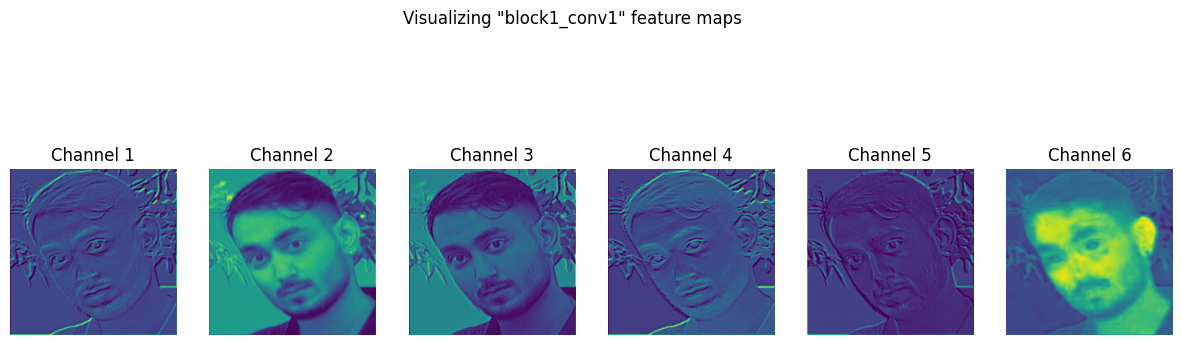

Layer: block3_conv1, Feature map shape: (1, 56, 56, 256)


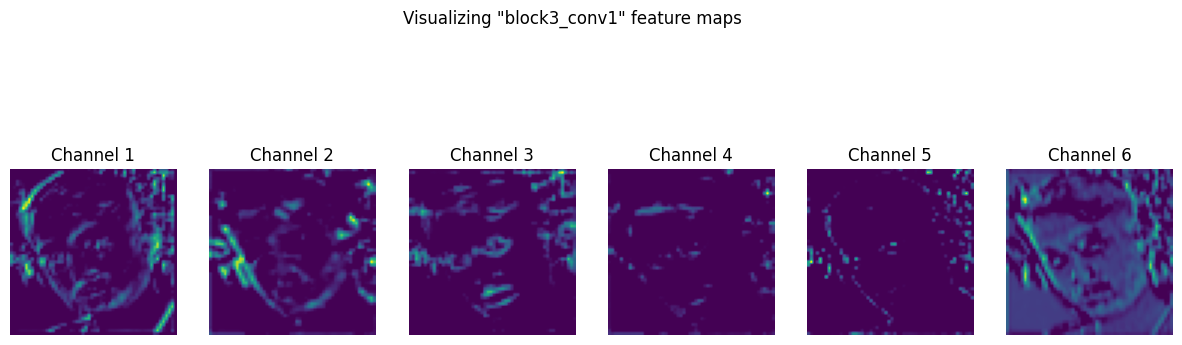

Layer: block5_conv4, Feature map shape: (1, 14, 14, 512)


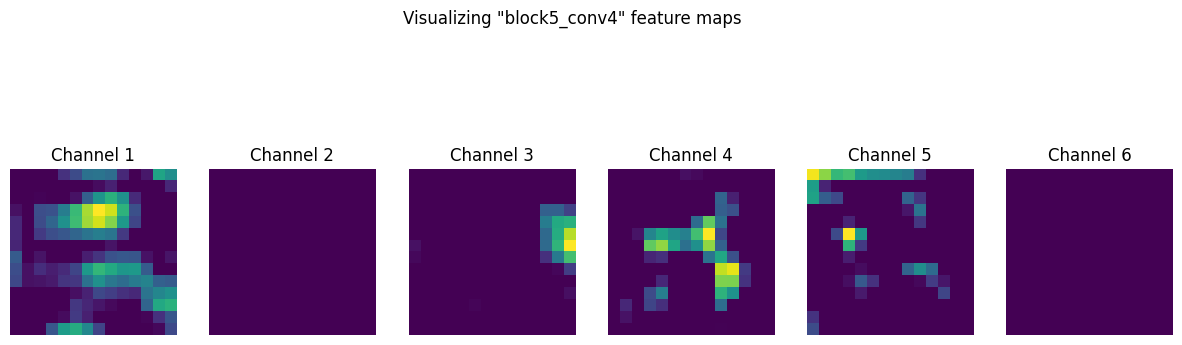

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

# Load your trained VGG19-based model
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg19 import preprocess_input

# Load and preprocess your image
image_path = r'C:\Users\Admin\Downloads\Doni_3_1.jpeg'

#image_path = r'C:\Users\Admin\Downloads\Doni_3_1.1.jpeg'


image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_resized = cv2.resize(image, (224, 224))
img_array = np.expand_dims(image_resized, axis=0) / 255.0

# Specify layers of interest for visualization
layer_names = [
    'block1_conv1',  # Early low-level feature layer
    'block3_conv1',  # Mid-level feature layer
    'block5_conv4'   # Deeper semantic feature layer
]

# Create intermediate model to fetch outputs
layer_outputs = [model.get_layer(name).output for name in layer_names]
intermediate_model = Model(inputs=model.input, outputs=layer_outputs)

# Get intermediate outputs
intermediate_outputs = intermediate_model.predict(img_array)

# Visualize each layer's outputs
for layer_name, feature_maps in zip(layer_names, intermediate_outputs):
    print(f"Layer: {layer_name}, Feature map shape: {feature_maps.shape}")

    # Visualize first few channels (up to 6 channels)
    num_channels = min(6, feature_maps.shape[-1])
    fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))
    fig.suptitle(f'Visualizing "{layer_name}" feature maps')

    for i in range(num_channels):
        axes[i].imshow(feature_maps[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Channel {i+1}')
    plt.show()


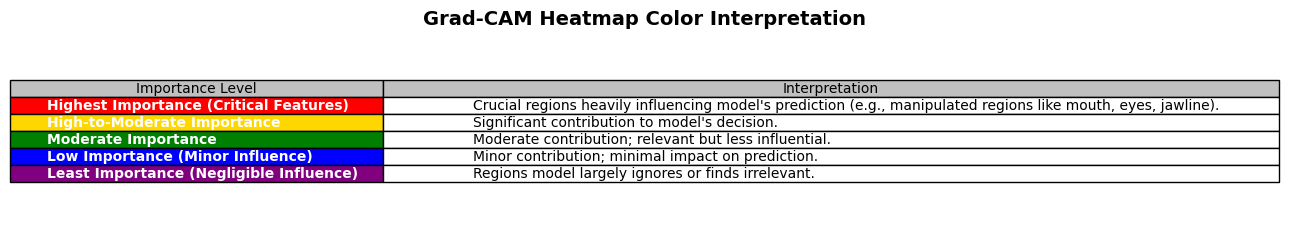

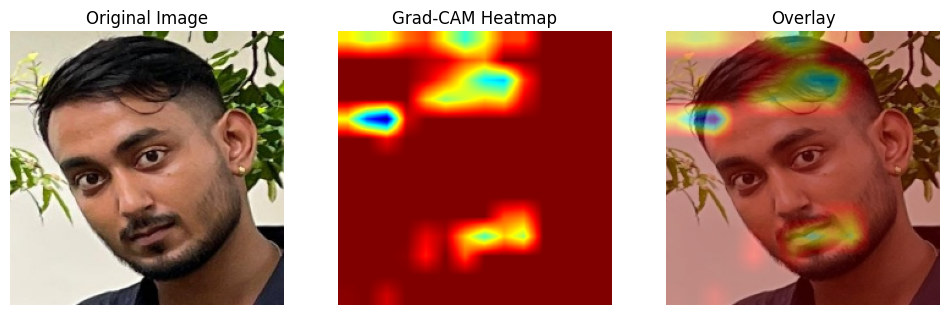

In [8]:
def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        output = predictions[:, pred_index]

    grads = tape.gradient(output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    return heatmap  # <-- Removed .numpy() from here
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define Grad-CAM interpretation details
colors = ['#FF0000', '#FFD700', '#008000', '#0000FF', '#800080']  # Red, Yellow, Green, Blue, Purple
importance_levels = [
    "Highest Importance (Critical Features)",
    "High-to-Moderate Importance",
    "Moderate Importance",
    "Low Importance (Minor Influence)",
    "Least Importance (Negligible Influence)"
]
interpretation = [
    "Crucial regions heavily influencing model's prediction (e.g., manipulated regions like mouth, eyes, jawline).",
    "Significant contribution to model's decision.",
    "Moderate contribution; relevant but less influential.",
    "Minor contribution; minimal impact on prediction.",
    "Regions model largely ignores or finds irrelevant."
]

# Create a figure and axis for the table
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')  # Hide axes

table_data = []
for color, importance, desc in zip(colors, importance_levels, interpretation):
    table_data.append([importance, desc])

table = ax.table(
    cellText=table_data,
    colLabels=["Importance Level", "Interpretation"],
    cellLoc='left',
    loc='center',
    colColours=["#C0C0C0"]*2  # Silver header
)

# Coloring the rows according to Grad-CAM interpretation
for i, color in enumerate(colors):
    table[(i+1, 0)].set_facecolor(color)
    table[(i+1, 0)].set_text_props(color='white', weight='bold')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(table_data[0]))))

plt.title("Grad-CAM Heatmap Color Interpretation", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

def visualize_gradcam(image_path, model, last_conv_layer_name):
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(original_img, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0) / 255.0

    # Generate Grad-CAM heatmap
    heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Overlay heatmap onto the original image
    heatmap_resized = cv2.resize(heatmap, (img_resized.shape[1], img_resized.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_resized = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img_resized, 0.6, heatmap_resized, 0.4, 0)

    # Plot
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.imshow(img_resized)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized)
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed_img)
    plt.title('Overlay')
    plt.axis('off')

    plt.show()

# Grad-CAM usage example
last_conv_layer_name = 'block5_conv4' # for VGG19
visualize_gradcam(image_path, model, last_conv_layer_name)
